## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

In [58]:
df = pd.read_csv('../../Day 2/lab-eda-univariate/amz_uk_price_prediction_dataset.csv')

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 495.8 MB


In [7]:
df.sample(10)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2043036,2307514,B0CFPJ36ND,rtdgcv Suit Bag Garment Bag Business Men's Ves...,0.0,0,19.46,False,0,Sports & Outdoors
1769842,1992257,B0CB8M4QB6,Money Belts for Travel Hidden Travel Money Bel...,3.3,5,3.59,False,50,Luggage and travel gear
914685,995892,B0BPT9KFB4,MUDUH Women Valentine's Day Heart Printing Cas...,0.0,0,4.89,False,0,Sports & Outdoors
459918,494652,B0CFGL1DYH,Men's Rain Jacket Waterproof Ski Jacket Warm C...,0.0,0,57.55,False,0,Sports & Outdoors
951818,1038842,B0CD1KZSLD,T-Shirts & Shirts Shirt Casual Solid Half Slee...,0.0,0,3.69,False,0,Sports & Outdoors
1112931,1231090,B00CALKGCO,Palace 50400 Langlow Turpentine Substitute 750...,4.6,54,2.95,False,0,"Painting Supplies, Tools & Wall Treatments"
1317739,1455753,B07XD5C7Z7,Castle Hot Tubs Geo-Bubble Silver/Blue METRES ...,0.0,0,159.00,False,0,"Pools, Hot Tubs & Supplies"
1508754,1684002,B0C2HQZM1P,Muscle Shirt Men's Slim Fit Stretch T-Shirt Me...,0.0,0,7.48,False,0,Sports & Outdoors
1868872,2098761,B08ZSKBZ3W,Birthday Cards Multipack of 24. Each Birthday ...,4.6,733,10.95,False,100,Office Paper Products
1914703,2155968,B06XKY17K3,Spear & Jackson CUTTINGSET15 Compact Ratchet &...,4.2,125,18.28,False,50,Garden Tools & Watering Equipment


### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [53]:
top_cat_bestsellers = pd.crosstab(df['category'], df['isBestSeller'])
top_cat_bestsellers

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [50]:
top_cat_bestsellers_norm = pd.crosstab(df['category'], df['isBestSeller'], normalize='index').sort_values(ascending=False, axis=0,by=True)
top_cat_bestsellers_norm

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
...,...,...
"CD, Disc & Tape Players",1.000000,0.000000
General Music-Making Accessories,1.000000,0.000000
Snowboard Boots,1.000000,0.000000


In [51]:
list(top_cat_bestsellers_norm[:3].index)

['Grocery', 'Smart Home Security & Lighting', 'Health & Personal Care']

2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

In [55]:
_, chi2_pvalue, _, _  = chi2_contingency(top_cat_bestsellers)
print(f"p-value: {chi2_pvalue:.20g}")

p-value: 0


In [45]:
cramer_value = association(top_cat_bestsellers, method='cramer')
cramer_value

0.12228294397605641

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

In [63]:
quartile_1 = df['price'].quantile(0.25)
quartile_3 = df['price'].quantile(0.75)
iqr_condition = (df['price'] > quartile_1) & (df['price'] < quartile_3)

df_iqr = df[iqr_condition]

In [ ]:
df_iqr.sample(10)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
1364422,1503688,B0CC26VKV3,"71Nmly Magnetic Color Sorting Board,Montessori...",2.0,1,11.80,False,0,Learning & Education Toys
1054075,1163853,B0CD68R6R9,"Wireless WiFi Transmitter Module, 120 Degree W...",0.0,0,32.29,False,0,Surveillance Cameras
795581,857195,B08HJ1261X,Tecnodidattica – NATGEO Classic Globe | Illumi...,4.7,65,40.99,False,0,School & Educational Supplies
1857759,2086804,B08ZDDJY7C,La Roche-Posay Hyalu B5 Aquagel SPF30 50ml,4.4,436,27.59,False,300,Beauty
2439222,2821076,B0CCZGMN26,CHICIRIS Dustproof Table Cover Silver Coated D...,0.0,0,25.85,False,0,Table Tennis
341860,365981,B0BT96KMQR,BBC Go Kit BBC Programmable Education Learning...,0.0,0,37.37,False,0,Barebone PCs
639503,688172,B00GEBBFN0,"NB London Dry Gin, 70 cl",4.6,50,35.07,False,0,"Beer, Wine & Spirits"
1091088,1205418,B009NHXE22,Genuine HOTPOINT Grey Dishwasher CUTLERY BASKET,4.5,373,13.89,False,100,Large Appliances
687398,741479,B08ZCPR3D8,"Bonnlo 1.8L Multi-Use Glass Electric Kettle, 2...",3.6,249,13.29,False,0,Small Kitchen Appliances
524522,565175,B0BY9K9B9S,T-Shirt Men's Set Consisting of Two-Piece Ruff...,0.0,0,11.21,False,0,Sports & Outdoors


In [62]:
df_iqr.info()

<class 'pandas.DataFrame'>
Index: 1202682 entries, 0 to 2443646
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   uid                1202682 non-null  int64  
 1   asin               1202682 non-null  str    
 2   title              1202682 non-null  str    
 3   stars              1202682 non-null  float64
 4   reviews            1202682 non-null  int64  
 5   price              1202682 non-null  float64
 6   isBestSeller       1202682 non-null  bool   
 7   boughtInLastMonth  1202682 non-null  int64  
 8   category           1202682 non-null  str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 252.7 MB


1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

In [70]:
top_20_cat = pd.DataFrame(df_iqr['category'].value_counts()[:20])
top_20_cat

,count
category,
Sports & Outdoors,427311
Women,11787
Men,11605
Birthday Gifts,10893
Handmade Kitchen & Dining,10617
Handmade Artwork,10289
Fragrances,10266
Handmade Gifts,10188
Bath & Body,9930


In [98]:
top_20_cat_list = list(top_20_cat.index)
top_20_cat_list

['Sports & Outdoors',
 'Women',
 'Men',
 'Birthday Gifts',
 'Handmade Kitchen & Dining',
 'Handmade Artwork',
 'Fragrances',
 'Handmade Gifts',
 'Bath & Body',
 'Skin Care',
 'Luggage and travel gear',
 'Baby',
 'Handmade Home Décor',
 'Handmade Home & Kitchen Products',
 'Boys',
 'Handmade Jewellery',
 'Hair Care',
 'Handmade',
 'Handmade Clothing, Shoes & Accessories',
 'Beauty']

In [99]:
df_iqr_top_20 = df_iqr[df_iqr["category"].isin(top_20_cat_list)]
display(df_iqr_top_20.sample(20))

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
278778,296044,B0BFRYG8CV,"MenoGlow Gentle Rebalancing Crème Cleanser, 60...",5.0,2,19.99,False,0,Skin Care
1163017,1284768,B0BSLNBRMG,| Peter Rabbit Navy Top |Clothing for Babies &...,5.0,2,14.00,False,0,Baby
542703,585358,B085X5S272,"Ellesse Siobhen Crew Sweat Sweatshirt, Girls, ...",5.0,3,29.99,False,0,Sports & Outdoors
1880607,2111209,B0C624YH1H,"banapoy Swim Buoy Float, Swimming Bubble Safet...",0.0,0,44.14,False,0,Sports & Outdoors
2064728,2333082,B077YFWTYP,Dynafit Women's Graphic Cotton S/S Tee Damen T...,5.0,1,31.99,False,0,Sports & Outdoors
2117041,2443044,B0C2ZP1X5G,CMP Girl's waterproof jacket,0.0,0,40.00,False,0,Sports & Outdoors
1816044,2042589,B0CG484Q6D,DOITOOL Bike Chain Lock 3pcs Bike Lock Chain B...,0.0,0,26.68,False,0,Sports & Outdoors
1761500,1983351,B075WVJPKF,Unisex 20l Ultralight Breathable Waterproof Ba...,4.5,3778,32.99,False,50,Luggage and travel gear
179309,192111,B09DCYC8MQ,Bruno Banani Pure Woman Eau de Toilette 50 ml,4.6,423,26.54,False,0,Fragrances
2228715,2575859,B0C4GNQ81M,Japace Interactive Felt Busy Board for Kid Ear...,4.6,32,17.99,False,100,Baby


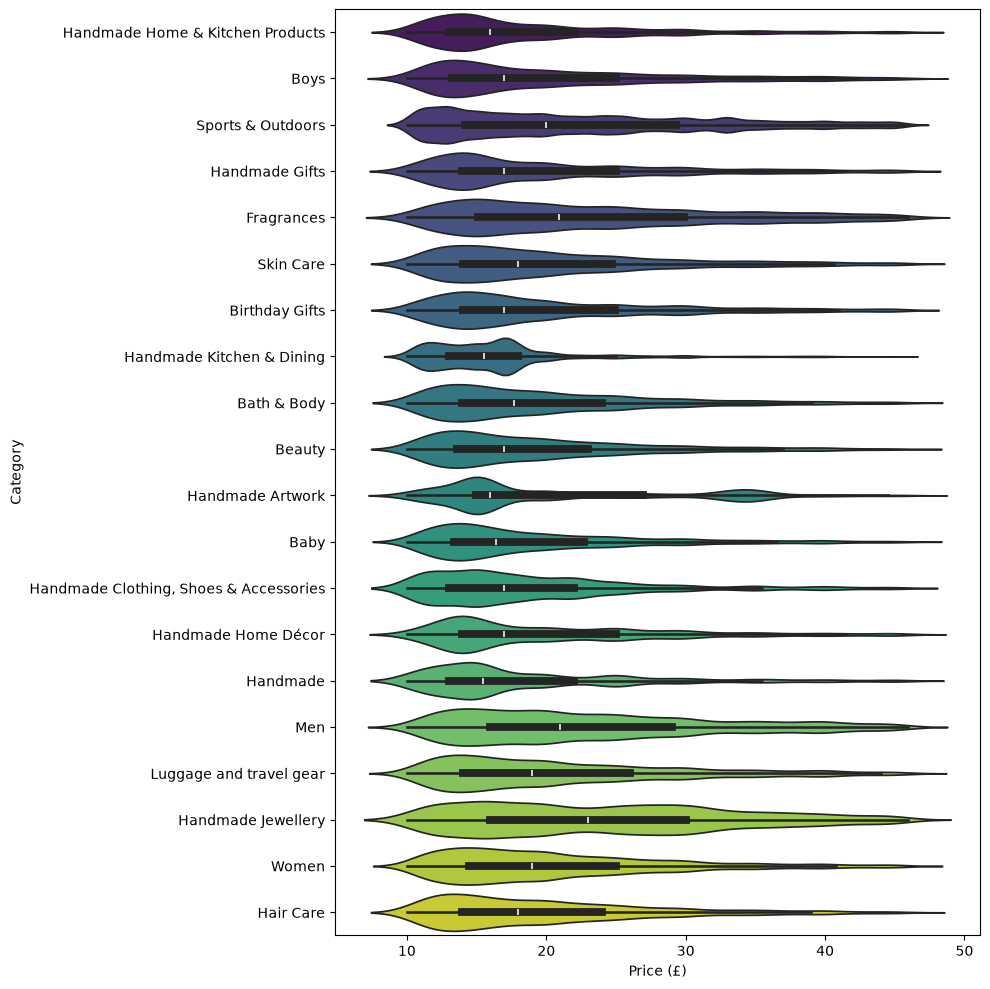

In [107]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.violinplot(
    data=df_iqr_top_20,
    x="price",
    y="category",
    hue="category",
    palette="viridis",
    legend=False
)

plt.xlabel("Price (£)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [ ]:
df_iqr[['category','price']].sort_values(by='price')

,category,price
2343584,Outdoor Lighting,10.00
1321983,Health & Personal Care,10.00
1608494,Handmade,10.00
1740131,Handmade Baby Products,10.00
2204910,Hair Care,10.00
...,...,...
145078,Sports & Outdoors,45.98
767372,Sports & Outdoors,45.98
767371,Sports & Outdoors,45.98
174895,Fragrances,45.98


In [116]:
pd.DataFrame(df_iqr.groupby("category")["price"].median().round(2)).sort_values(by='price',ascending=False)

,price
category,
Graphics Cards,42.29
Hockey Shoes,39.77
Computer Cases,38.97
"Motorbike Handlebars, Controls & Grips",35.90
Downhill Skis,35.29
...,...
Cables & Accessories,14.00
Signs & Plaques,13.99
Office Paper Products,13.99


2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

In [117]:
top_10_cat = pd.DataFrame(df_iqr['category'].value_counts()[:10])
top_10_cat_list = list(top_10_cat.index)
df_iqr_top_10 = df_iqr[df_iqr["category"].isin(top_10_cat_list)]

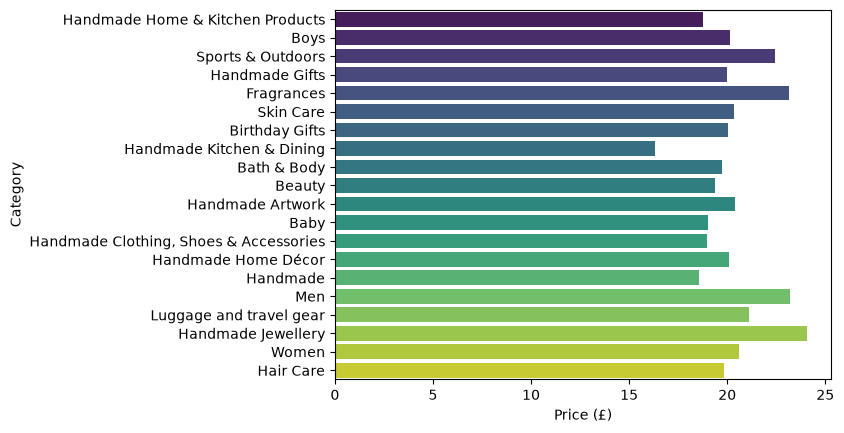

In [129]:
sns.barplot(
    data=df_iqr_top_20,
    x="price",
    y="category",
    hue="category",
    palette="viridis",
    legend=False,
    errorbar=None
)
plt.xlabel("Price (£)")
plt.ylabel("Category")
plt.show()

In [127]:
pd.DataFrame(df_iqr.groupby("category")["price"].mean().round(2)).sort_values(by='price',ascending=False)

,price
category,
Hockey Shoes,37.39
Graphics Cards,36.61
Computer Cases,35.46
"Motorbike Handlebars, Controls & Grips",34.90
Motorbike Batteries,34.70
...,...
Arts & Crafts,16.33
Handmade Kitchen & Dining,16.33
Mobile Phone Accessories,16.30


3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

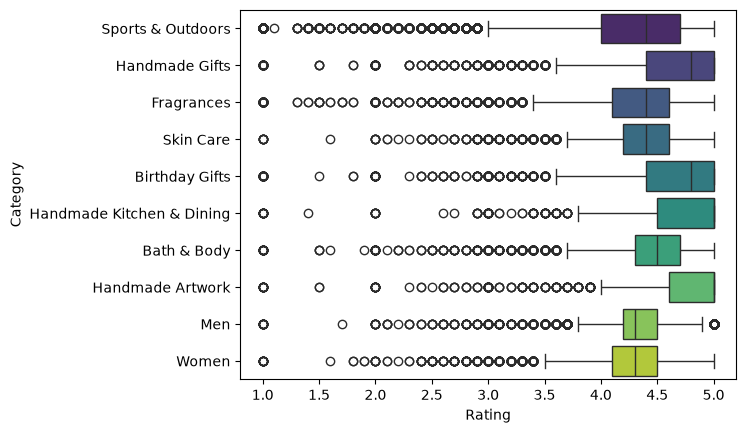

In [ ]:
non_zero_rating = df_iqr_top_10['stars'] > 0

sns.boxplot(
    data=df_iqr_top_10[non_zero_rating],
    x="stars",
    y="category",
    hue="category",
    palette="viridis",
    legend=False,
)

plt.xlabel("Rating")
plt.ylabel("Category")
plt.show()

In [134]:
pd.DataFrame(df_iqr.groupby("category")["stars"].median().round(3)).sort_values(by='stars',ascending=False)

,stars
category,
Computer Memory,4.6
Jigsaws & Puzzles,4.6
Grocery,4.6
Dolls & Accessories,4.6
Kids' Play Figures,4.6
...,...
Hi-Fi Receivers & Separates,0.0
Handmade Kitchen & Dining,0.0
Handmade Jewellery,0.0


### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [136]:
pearson_coeff = round(float(df_iqr["price"].corr(df_iqr["stars"], method="pearson")), 3)
spearman_coeff = round(float(df_iqr["price"].corr(df_iqr["stars"], method="spearman")), 3)
print(pearson_coeff, spearman_coeff)

-0.01 0.002


2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

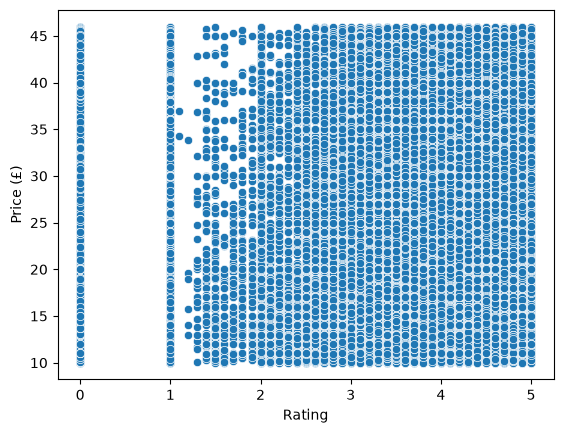

In [139]:
sns.scatterplot(data=df_iqr, x='stars', y='price')

plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.show()

In [153]:
df_iqr_num = df_iqr.select_dtypes(include="number")
df_iqr_num = df_iqr_num.drop(columns='uid')

correlation_matrix = df_iqr_num.corr()
correlation_matrix

,stars,reviews,price,boughtInLastMonth
stars,1.000000,0.087205,-0.009751,0.099137
reviews,0.087205,1.000000,-0.001658,0.107880
price,-0.009751,-0.001658,1.000000,-0.029059
boughtInLastMonth,0.099137,0.107880,-0.029059,1.000000


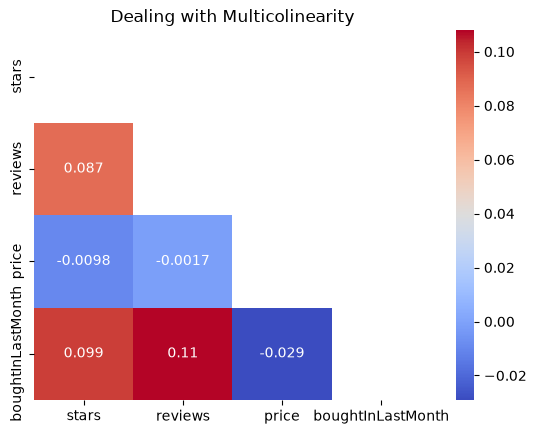

In [155]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm")

plt.title("Dealing with Multicolinearity")
plt.show()

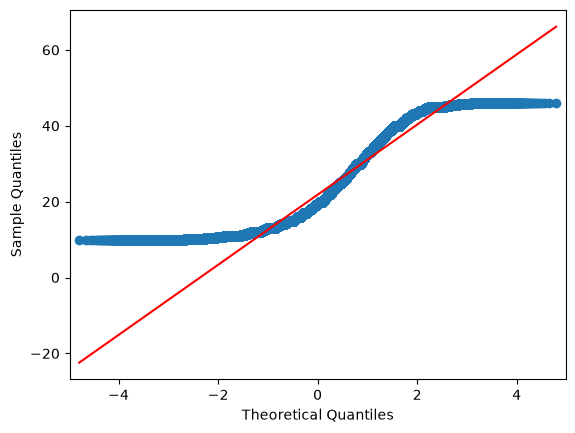

In [157]:
sm.qqplot(df_iqr['price'], line='s');
plt.show()

# Business Report

### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

- The top 3 categories where being a best-seller is more prevalent are Grocery, Smart Home Security & Lighting, Health & Personal Care, where close to 6% of their products are best-sellers.
- The obtained $\chi^2$ p-value between `category` and `isBestSeller` is very small, rounded to 0.0. Since it is smaller than 0.05, this suggests that there is a significant association between the variables.
- The measure of association between the two variables, given by the Cramér's V method, resulted in 0.12, representing a weak association strength. 

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

- The category 'Graphics Cards' tends to have the highest median price. In our dataset its mean price is £42.29.
- The category 'Computer Memory' tends to have the highest median rating. In our dataset its mean price is 4.6.

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

- Both Pearson and Spearman coefficients resulted in values close to zero which indicates no significant correlation between product price and its rating.
- From the scatter plot, one can observe that no pattern can be found, reinforcing what was found by the correlation coefficients.
- From the QQ plot, since the points curve away from the line, especially at the ends, prices are not normally distributed. The upward deviation in the upper tail indicates right skewness: a smaller number of products have much higher prices.

# Bonus 

Do the same analysis without taking out the outliers. What are your insights?

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

In [159]:
top_20_cat = pd.DataFrame(df['category'].value_counts()[:20])
top_20_cat

,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978
Manicure & Pedicure Products,18940
Skin Care,18769
Make-up,18756
Hair Care,18735


In [160]:
top_20_cat_list = list(top_20_cat.index)
top_20_cat_list

['Sports & Outdoors',
 'Beauty',
 'Handmade Clothing, Shoes & Accessories',
 'Bath & Body',
 'Birthday Gifts',
 'Manicure & Pedicure Products',
 'Skin Care',
 'Make-up',
 'Hair Care',
 'Fragrances',
 'Handmade Gifts',
 'Handmade Home Décor',
 'Luggage and travel gear',
 'Handmade Jewellery',
 'Handmade Artwork',
 'Women',
 'Handmade Home & Kitchen Products',
 'Handmade Kitchen & Dining',
 'Men',
 'Baby']

In [161]:
df_top_20 = df[df["category"].isin(top_20_cat_list)]
display(df_top_20.sample(20))

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
497513,534466,B08FT6Q8RK,Scicent High Waist Yoga Pants with Pockets Tum...,4.3,269,20.76,False,0,Sports & Outdoors
1782334,2006244,B0BRQJPMY4,"Clicitina Natural drying fibre, chemical free,...",0.0,0,10.30,False,0,Sports & Outdoors
629725,678166,B07G76T7FY,Spongellé Romanticism Collection Shower Body W...,5.0,13,13.95,False,0,Bath & Body
358022,382676,B0CBWL2P9T,Gym Fitness Aerobic Step Springboard Adjustabl...,0.0,0,460.99,False,0,Sports & Outdoors
2230087,2577283,B01HTIFSFC,Clippasafe Adjustable Strap Soft and Breathabl...,4.1,149,9.61,False,50,Baby
470356,505451,B0BDKWXKRT,Trekking Trousers Men's XXL Tactical Trousers ...,0.0,0,15.54,False,0,Sports & Outdoors
1810348,2036235,B0C85VMDY7,UNARAY 10pc Bicycle Gear Rear Derailleur Hange...,0.0,0,47.42,False,0,Sports & Outdoors
963169,1056050,B0CGPC2R74,Lightweight Fleece Jacket Women Women's Christ...,0.0,0,12.09,False,0,Sports & Outdoors
941241,1026033,B0CBZMNRVZ,"Eulbevoli Fishing Vest, Multi Pockets Adjustab...",0.0,0,18.39,False,0,Sports & Outdoors
2014438,2265890,B0BN3Q5R8N,Multifunctional Foldable Treadmill Household R...,0.0,0,1239.99,False,0,Sports & Outdoors


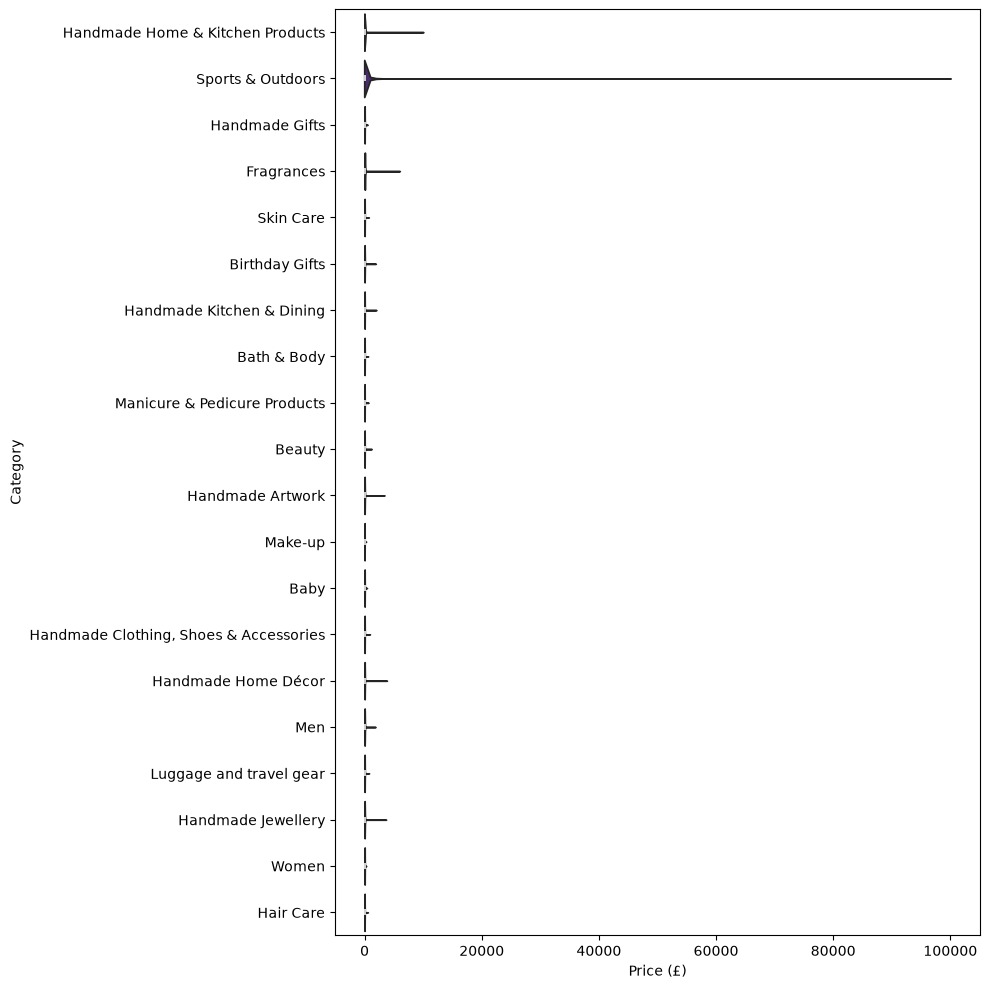

In [162]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.violinplot(
    data=df_top_20,
    x="price",
    y="category",
    hue="category",
    palette="viridis",
    legend=False
)

plt.xlabel("Price (£)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [164]:
pd.DataFrame(df.groupby("category")["price"].median().round(2)).sort_values(by='price',ascending=False)

,price
category,
Laptops,1042.72
Desktop PCs,810.40
Snowboards,366.72
Home Audio Record Players,326.08
3D Printers,319.00
...,...
Adapters,7.05
Make-up,7.00
Signs & Plaques,6.99


2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

In [165]:
top_10_cat = pd.DataFrame(df['category'].value_counts()[:10])
top_10_cat_list = list(top_10_cat.index)
df_top_10 = df[df["category"].isin(top_10_cat_list)]

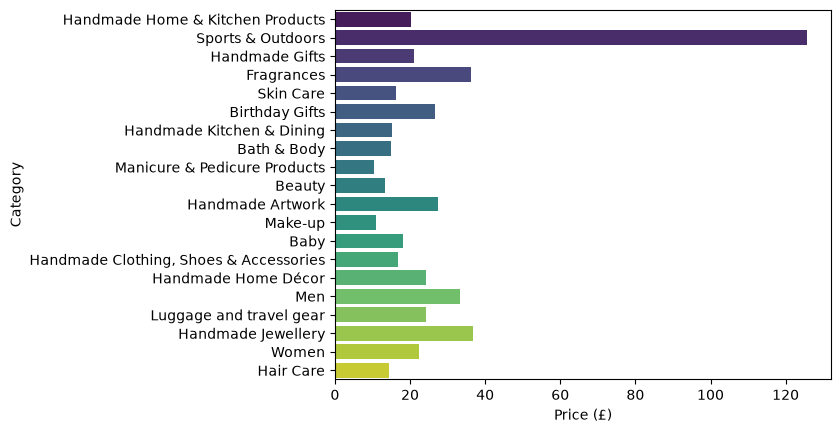

In [166]:
sns.barplot(
    data=df_top_20,
    x="price",
    y="category",
    hue="category",
    palette="viridis",
    legend=False,
    errorbar=None
)
plt.xlabel("Price (£)")
plt.ylabel("Category")
plt.show()

In [167]:
pd.DataFrame(df.groupby("category")["price"].mean().round(2)).sort_values(by='price',ascending=False)

,price
category,
Laptops,1087.99
3D Printers,1018.04
Desktop PCs,926.82
Home Office Furniture,622.14
Test & Measurement,559.38
...,...
Bedding Accessories,8.84
Adapters,8.75
Signs & Plaques,8.28


3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

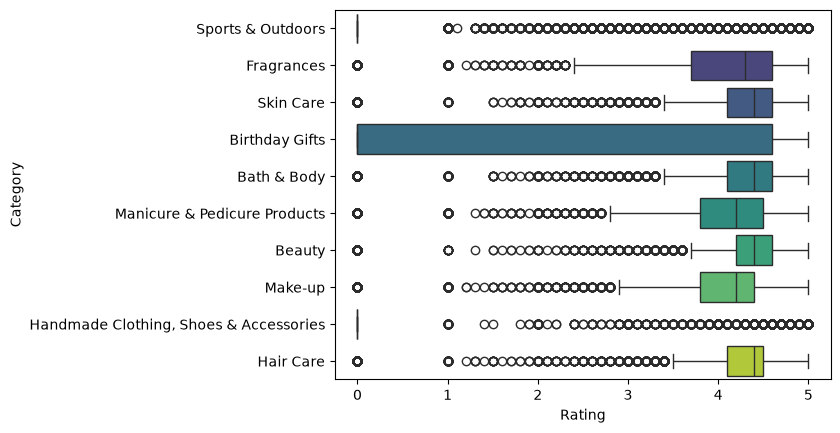

In [170]:
sns.boxplot(
    data=df_top_10,
    x="stars",
    y="category",
    hue="category",
    palette="viridis",
    legend=False,
)

plt.xlabel("Rating")
plt.ylabel("Category")
plt.show()

In [171]:
pd.DataFrame(df.groupby("category")["stars"].median().round(3)).sort_values(by='stars',ascending=False)

,stars
category,
Computer Memory,4.7
Hobbies,4.6
"Beer, Wine & Spirits",4.6
Laptop Accessories,4.6
Kids' Play Figures,4.6
...,...
KVM Switches,0.0
Karaoke Equipment,0.0
Lab & Scientific Products,0.0


### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [172]:
pearson_coeff = round(float(df["price"].corr(df["stars"], method="pearson")), 3)
spearman_coeff = round(float(df["price"].corr(df["stars"], method="spearman")), 3)
print(pearson_coeff, spearman_coeff)

-0.125 -0.133


2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

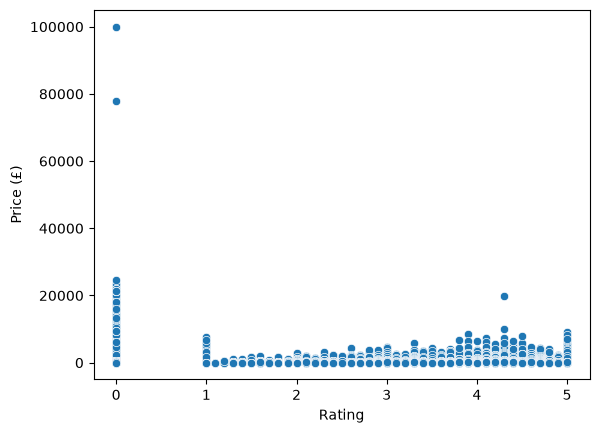

In [173]:
sns.scatterplot(data=df, x='stars', y='price')

plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.show()

In [174]:
df_num = df.select_dtypes(include="number")
df_num = df_num.drop(columns='uid')

correlation_matrix = df_num.corr()
correlation_matrix

,stars,reviews,price,boughtInLastMonth
stars,1.000000,0.085808,-0.124907,0.112536
reviews,0.085808,1.000000,-0.013171,0.104043
price,-0.124907,-0.013171,1.000000,-0.023439
boughtInLastMonth,0.112536,0.104043,-0.023439,1.000000


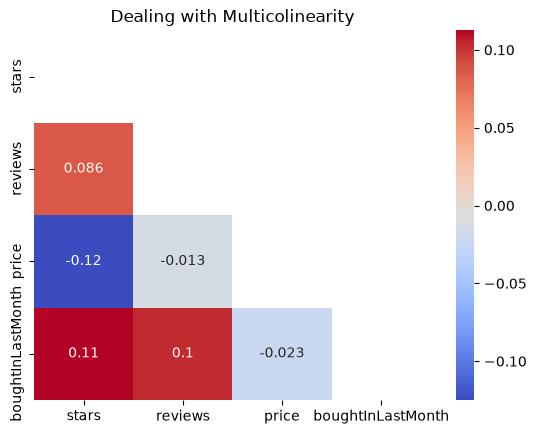

In [175]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm")

plt.title("Dealing with Multicolinearity")
plt.show()

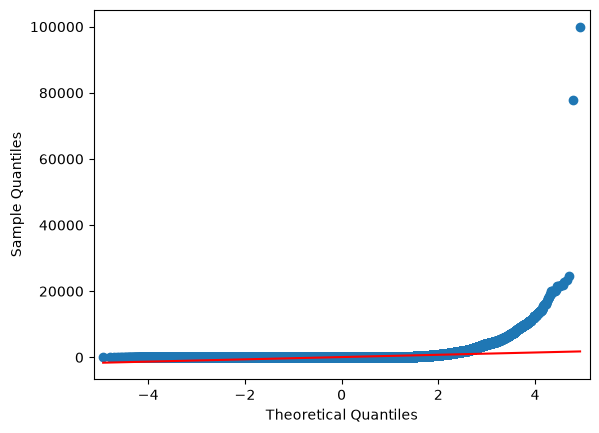

In [176]:
sm.qqplot(df['price'], line='s');
plt.show()